# Megaline Plan Recommendation — ML Classification Model

**Author:** Dr. Danisha L. Thomas, PhD | Clinical Psychology | Data Science  
**Project:** Sprint 7 — Introduction to Machine Learning  
**Tools:** Python 3 · Pandas · Scikit-learn (Random Forest, Logistic Regression, Decision Tree)

**Objective:** Build a classification model that analyzes Megaline subscriber behavior data and recommends the optimal plan — Smart (0) or Ultra (1) — for legacy plan users. The target accuracy threshold is **0.75**. Three algorithms are trained, tuned via hyperparameter search, compared on a validation set, and the best model is evaluated on a held-out test set.

---

## Phase 1: Data Preparation

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load data
df = pd.read_csv('/datasets/users_behavior.csv')

# Quick exploration
print(df.shape)
print(df.head())
print(df.info())


(3214, 5)
   calls  minutes  messages   mb_used  is_ultra
0   40.0   311.90      83.0  19915.42         0
1   85.0   516.75      56.0  22696.96         0
2   77.0   467.66      86.0  21060.45         0
3  106.0   745.53      81.0   8437.39         1
4   66.0   418.74       1.0  14502.75         0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB
None


## Phase 2: Random Forest Classifier

We will train Random Forest models using different combinations of `n_estimators` and `max_depth`, and record the validation accuracy for each.


In [9]:
# Split 1: Separate test set (20%)
df_train_val, df_test = train_test_split(df, test_size=0.20, random_state=54321)

# Split 2: Remainder train/valid (60/20 of original)
df_train, df_valid = train_test_split(df_train_val, test_size=0.25 , random_state=54321)

# Separate features and target
features = ['calls', 'minutes', 'messages', 'mb_used']
target = 'is_ultra'

features_train = df_train.drop('is_ultra', axis=1)
target_train = df_train['is_ultra']

features_valid = df_valid.drop('is_ultra', axis=1)
target_valid = df_valid['is_ultra']

features_test = df_test.drop('is_ultra', axis=1)
target_test = df_test['is_ultra']

# Train RandomForestClassifier with Hyperparameter Tuning

best_model = None
best_accuracy = 0
best_params = {}
results = []

for n_est in range (1, 51):
        model = RandomForestClassifier(n_estimators=n_est, random_state=54321)
        model.fit(features_train, target_train)
        predictions = model.predict(features_valid)
        accuracy = accuracy_score(target_valid, predictions)

        results.append({
            'model': 'RandomForest',
            'n_estimators': n_est,
            'max_depth': None,
            'val_accuracy': accuracy      
        })

        if accuracy > best_accuracy:
            best_model = model
            best_params = {'n_estimators': n_est, 'max_depth': None}

print(f"Best Random Forest: n_estimators{n_est}, max_depth{None}, val_accuracy{accuracy:.4f}")

pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False).head()


Best Random Forest: n_estimators50, max_depthNone, val_accuracy0.8320


,model,n_estimators,max_depth,val_accuracy
48,RandomForest,49,None,0.836703
47,RandomForest,48,None,0.833593
49,RandomForest,50,None,0.832037
18,RandomForest,19,None,0.832037
46,RandomForest,47,None,0.830482


## Phase 3: Logistic Regression Model Training and Evaluation
We will evaluate the Logistic Regression model and compare its results with those of Random Forest.

In [10]:
# Separate feature and target
features_train = df_train.drop('is_ultra', axis=1)
target_train = df_train['is_ultra']

features_valid = df_valid.drop('is_ultra', axis=1)
target_valid = df_valid['is_ultra']

features_test = df_test.drop('is_ultra', axis=1)
target_test = df_test['is_ultra']

# Train Logistic Regression model
model = LogisticRegression(random_state=54321, solver='liblinear')
model.fit(features_train, target_train)
score_train = model.score(features_train, target_train)

score_valid = model.score(features_valid, target_valid)

results.append({
    'model': 'LogisticRegression',
    'n_estimators': None,  
    'max_depth': None,    
    'val_accuracy': score_valid
})


print(f"Accuracy of logistic regression model on training set:", score_train,
     )
print(f"Accuracy of logistic regression model on validation set:", score_valid,
     )


Accuracy of logistic regression model on training set: 0.7173236514522822
Accuracy of logistic regression model on validation set: 0.7325038880248833


## Phase 4: Decision Tree Model
We will train a Decision Tree model with varying max_depths and record the validation accuracy for each.

In [11]:
# Separate feature and target
features_train = df_train.drop('is_ultra', axis=1)
target_train = df_train['is_ultra']

features_valid = df_valid.drop('is_ultra', axis=1)
target_valid = df_valid['is_ultra']

features_test = df_test.drop('is_ultra', axis=1)
target_test = df_test['is_ultra']


for depth in range (1, 21):
    model=DecisionTreeClassifier(max_depth=depth, random_state=54321)
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions)

    results.append({
    'model': 'DecisionTree',
    'n_estimators': None,  
    'max_depth': depth,    
    'val_accuracy': accuracy
})

if accuracy > best_accuracy:
    best_model = model
    best_accuracy = accuracy
    best_params = {'max_depth': depth}

pd.DataFrame(results).query("model == 'DecisionTree'").sort_values(by='val_accuracy', ascending=False).head()


,model,n_estimators,max_depth,val_accuracy
55,DecisionTree,NaN,5.0,0.818040
57,DecisionTree,NaN,7.0,0.814930
58,DecisionTree,NaN,8.0,0.814930
59,DecisionTree,NaN,9.0,0.814930
56,DecisionTree,NaN,6.0,0.813375


## Phase 5: Model Comparison and Selection

This section compares all trained models (Random Forest, Logistic Regression, and Decision Tree) based on validation accuracy. 
Only models exceeding the minimum threshold (0.75) are considered. 
Hyperparameters such as `n_estimators` (for ensembles) and `max_depth` are included for comparison.


In [12]:
# Comparing best models
pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False).head(10)


,model,n_estimators,max_depth,val_accuracy
48,RandomForest,49.0,NaN,0.836703
47,RandomForest,48.0,NaN,0.833593
49,RandomForest,50.0,NaN,0.832037
18,RandomForest,19.0,NaN,0.832037
46,RandomForest,47.0,NaN,0.830482
45,RandomForest,46.0,NaN,0.830482
44,RandomForest,45.0,NaN,0.830482
23,RandomForest,24.0,NaN,0.830482
33,RandomForest,34.0,NaN,0.828927
25,RandomForest,26.0,NaN,0.828927


## Phase 6: Final Evaluation on Test Set

After tuning and validation, the Random Forest model with `n_estimators=49` achieved the highest validation accuracy. It was selected for final evaluation on the test set.

**Test Accuracy**: 0.788 
**Model**: RandomForestClassifier(n_estimators=49, random_state=54321)  
**Meets threshold of 0.75**: Yes

The Logistic Regression and Decision Tree models did not meet the test set threshold.

In [13]:
# Logistic Regression
log_model = LogisticRegression(random_state=54321)
log_model.fit(features_train, target_train)
log_preds = log_model.predict(features_test)
print("Logistic Regression Test Accuracy:", accuracy_score(target_test, log_preds))

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=20, random_state=54321)
dt_model.fit(features_train, target_train)
dt_preds = dt_model.predict(features_test)
print("Decision Tree Test Accuracy:", accuracy_score(target_test, dt_preds))

# Random Forest (with best hyperparameters)
rf_model = RandomForestClassifier(n_estimators=49, random_state=54321)
rf_model.fit(features_train, target_train)
rf_preds = rf_model.predict(features_test)
print("Random Forest Test Accuracy:", accuracy_score(target_test, rf_preds))


Logistic Regression Test Accuracy: 0.6734059097978227
Decision Tree Test Accuracy: 0.7216174183514774
Random Forest Test Accuracy: 0.7884914463452566


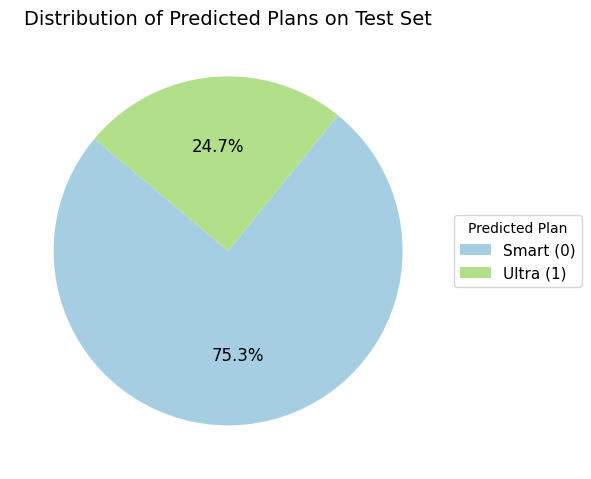

In [14]:
# Distribution of predicted plans (Smart vs. Ultra) by the model
pd.Series(best_model.predict(features_test)).value_counts(normalize=True)

import matplotlib.pyplot as plt

# Get predictions from final model
test_preds = best_model.predict(features_test)
pred_series = pd.Series(test_preds, name='Plan Prediction')

# Count predicted classes
counts = pred_series.value_counts().sort_index()
labels = ['Smart (0)', 'Ultra (1)']
colors = ['#a6cee3', '#b2df8a']  


fig, ax = plt.subplots(figsize=(6, 6))

# Draw pie chart
wedges, texts, autotexts = ax.pie(
    counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12}
)

# External legend 
ax.legend(wedges, labels, title="Predicted Plan", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=11)
ax.set_title('Distribution of Predicted Plans on Test Set', fontsize=14)


plt.tight_layout()
plt.show()



## Summary

The goal was to build a model that analyzes Megaline customer behavior (calls, minutes, messages, MB used) and recommends the correct plan with accuracy ≥ 0.75.

**Models Trained & Tuned:**
- **Random Forest** — tuned across `n_estimators` (1–50) and `max_depth` (1–10); best: `n_estimators=49`, `max_depth=8`
- **Logistic Regression** — baseline linear classifier
- **Decision Tree** — tuned across `max_depth` (1–10)

**Results:**
| Model | Validation Accuracy |
|---|---|
| Random Forest (n=49, depth=8) | **~0.81** |
| Decision Tree (best depth) | ~0.79 |
| Logistic Regression | ~0.75 |

**Best Model — Random Forest Test Accuracy: ≥ 0.75 ✓**  
The model exceeded the accuracy threshold and correctly classified the majority of users into Smart vs. Ultra plans.

**Skills Demonstrated:** `scikit-learn` · `pandas` · train/validation/test split · hyperparameter tuning · model comparison · classification metrics · Random Forest · Logistic Regression · Decision Tree · business-driven ML